# Plot distance vs dt for hammer strikes

## Load modules

In [3]:
import numpy as np
import pandas as pd
import math

import glob
import os

import matplotlib.pylab as plt
from matplotlib.gridspec import GridSpec

from obspy import read, UTCDateTime

from scipy.fftpack import fft, fftfreq, next_fast_len

%load_ext autoreload
%autoreload 2
%matplotlib inline 
%matplotlib widget

In [4]:
def calculate_distance(point1, point2):
    # Unpack points
    x1, y1 = point1
    x2, y2 = point2
    
    # Calculate the distance
    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return distance

# Function to calculate Euclidean distance from point (px, py) to (x, y)
def calculate_distance_df(row, px, py):
    return np.sqrt((row['lon'] - px) ** 2 + (row['lat'] - py) ** 2)

def calculate_distance(row):
    dlon = row['ev_lon'] - row['lon']
    dlat = row['ev_lat'] - row['lat']
    distance = np.sqrt(dlon**2 + dlat**2)
    return distance

def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return freq, spec 

def onclick(event):
    if event.inaxes != ax:
        return
    points.append((event.xdata, event.ydata))
    if len(points) == 2:
        x1, y1 = points[0]
        x2, y2 = points[1]
        slope = (x2 - x1) / (y2 - y1)
        print(f"Point 1: ({x1}, {y1})")
        print(f"Point 2: ({x2}, {y2})")
        print(f"Slope: {slope}")
        points.clear()  # Clear points to allow for new selection



## Load files for one hammer strike

#### Read all pick files in one go

In [11]:
# not well picked
path_to_strikewise_folder = "strike_wise"

picks_file_name = "PICKS_LAST_YEAR/HS11copy.txt"

# for saving some outputs
save_path = os.path.dirname(picks_file_name)

#### Loading data into one pandas dataframe

In [12]:
# Load picks 
path_to_picks = glob.glob(picks_file_name)
path_to_picks.sort()
print(path_to_picks)
collect_picks = []
for pick_path in path_to_picks:

    number_hammer_strike = int(pick_path.split('/')[-1].split('_')[0].split('HS')[-1])
    # print(pick_path, number_hammer_strike)

    # Load station info
    station_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/station_info_HS{number_hammer_strike:02d}.txt"))[0]
    sta_locs = pd.read_csv(station_info, header=None, comment="#", sep='\s+', names=['sta', 'lat', 'lon', 'elev', 'depth'])
    sta_locs['sta'] = sta_locs['sta'].str.replace(r'^SH\.|.$', '', regex=True)

    # Ensure 'sta' column in sta_locs is unique
    sta_locs = sta_locs.drop_duplicates(subset=['sta'])

    # Load 'event' info 
    event_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/event_info_HS{number_hammer_strike:02d}.txt"))[0]
    event = {}
    file1 = open(event_info, 'r')
    Lines1 = file1.readlines()
    for line in Lines1:
        if "longitude" in line.strip():
            event['longitude'] = float(line.strip().split('=')[1])
        elif "latitude" in line.strip():
            event['latitude'] = float(line.strip().split('=')[1])
        else:
            pass

    # put everything together into a pandas data frame 
    file = pick_path
    file2 = open(file, 'r')
    Lines2 = file2.readlines()
    count = 0

    session = 1  # Hard coded
    # phase = 'S'
    experiment = number_hammer_strike
    # Strips the newline character
    for line in Lines2:
        count += 1
        if "phase" in line.strip():
            strip_line = line.strip().split()
            try:
                net, sta, loc, cha = strip_line[4].split('.')
            except Exception as exp:
                print(exp)

            # if strip_line[8] == phase:
            collect_picks.append([UTCDateTime(f"{strip_line[1]}T{strip_line[2]}"), session, experiment, net, sta, strip_line[8], event['latitude'], event['longitude']])

df_picks = pd.DataFrame(collect_picks, columns = ['datetime',  'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat', 'ev_lon']) 

# # Merge the two DataFrames based on the 'sta' column
df_picks = pd.merge(df_picks, sta_locs, on='sta', how='left')

# # Apply the function to each row and save the result in a new column
# df_picks['distance_to_source'] = df_picks.apply(calculate_distance_df, axis=1, px=event['longitude'], py=event['latitude'])
df_picks['distance_to_source'] = df_picks.apply(calculate_distance, axis=1)

print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("\tUnique experiments:", df_picks['experiment'].unique())
print("Number of unique stations:", len(df_picks['sta'].unique()))
df_picks.head()

# df_picks['experiment'].value_counts().sort_index()


['PICKS_LAST_YEAR/HS11copy.txt']


ValueError: invalid literal for int() with base 10: '11copy.txt'

### Plot what you you loaded

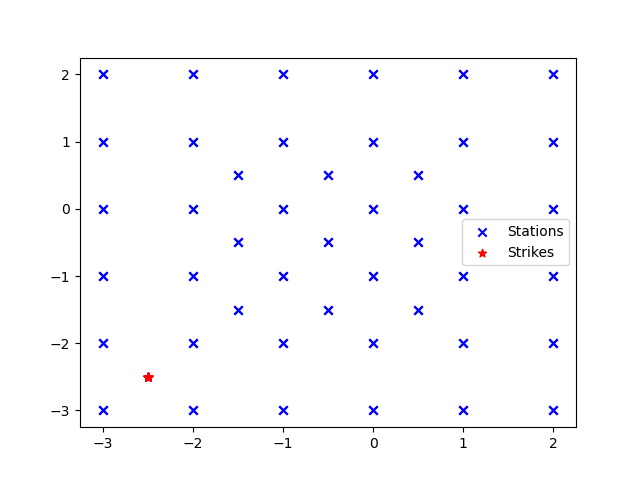

In [115]:
plt.figure()

plt.scatter(df_picks['lon'], df_picks['lat'], c='b', marker='x', label='Stations')
plt.scatter(df_picks['ev_lon'], df_picks['ev_lat'], c='r', marker='*', label='Strikes')
plt.legend()
plt.show()

## Distance vs Time plot with error bars

In [116]:
df_picks['phase'].unique()

array(['A'], dtype=object)

In [117]:
all_distances = df_picks['distance_to_source'].unique()
all_distances.sort()

df_picks['dt'] = None
df_picks['group'] = None
# Identify the rows where x is 0

for p, phase in enumerate(df_picks['phase'].unique()):
    for k, exp in enumerate(df_picks['experiment'].unique()):
        
        temp = df_picks[(df_picks['experiment']==exp) & (df_picks['phase']==phase)]
        first_station = temp['distance_to_source'].min()

        selected_df_exp = df_picks[(df_picks['distance_to_source'] == first_station) & (df_picks['experiment']==exp) & (df_picks['phase']==phase)]
        
        min_time = selected_df_exp['datetime'].values

        # Subtract these datetime values from the datetime values of rows where x is greater than 0
        count = 0
        for j, times in enumerate(min_time):
            for i, row in df_picks.iterrows():
                if (abs(row['datetime'] - min_time[j]) < 0.1) & (row['experiment'] == exp) & (row['phase']==phase):
                    df_picks.at[i, 'dt'] = row['datetime'] - min_time[j]
                    df_picks.at[i, 'group'] = j
                    # print(j)
                    count += 1
print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("Number of unique stations:", len(df_picks['sta'].unique()))

df_picks.head()

Number of all picks collected: 90
Number of unique experiments: 1
Number of unique stations: 45


,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,dt,group
0,2024-06-06T17:48:29.007780Z,1,39,SH,31598,A,-2.5,-2.5,-2.0,-2.0,0,0,0.707107,-0.00114,3
1,2024-06-06T17:48:29.008230Z,1,39,SH,31317,A,-2.5,-2.5,-3.0,-3.0,0,0,0.707107,-0.00069,3
2,2024-06-06T17:48:29.008920Z,1,39,SH,33105,A,-2.5,-2.5,-2.0,-3.0,0,0,0.707107,0.0,3
3,2024-06-06T17:48:29.008920Z,1,39,SH,32173,A,-2.5,-2.5,-3.0,-2.0,0,0,0.707107,0.0,3
4,2024-06-06T17:48:29.011440Z,1,39,SH,40350,A,-2.5,-2.5,-1.5,-1.5,0,0,1.414214,0.00252,3


#### Sanity test plot

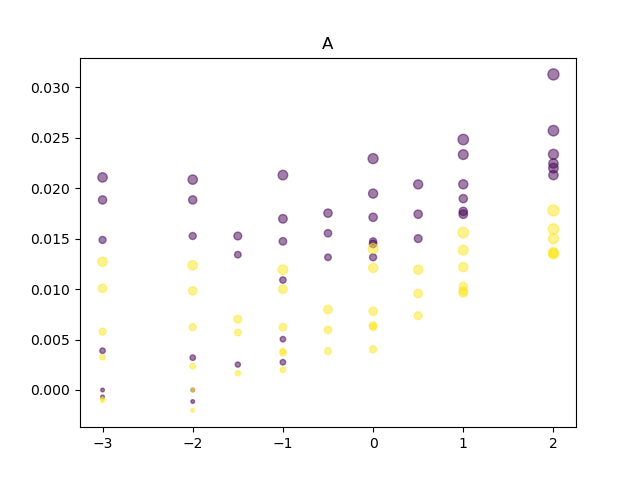

In [118]:
for p, phase in enumerate(df_picks['phase'].unique()):
    plt.figure()
    df_phase = df_picks[df_picks['phase'] == phase]
    # plt.scatter(df_picks['distance_to_source'], df_picks['dt'], s=df_picks['distance_to_source']*10, c=df_picks['group'], cmap='viridis', alpha=0.5)
    plt.scatter(df_phase['lon'], df_phase['dt'], s=df_phase['distance_to_source']*10, c=df_phase['group'], cmap='viridis', alpha=0.5)
    plt.title(f'{phase}')
    plt.show()

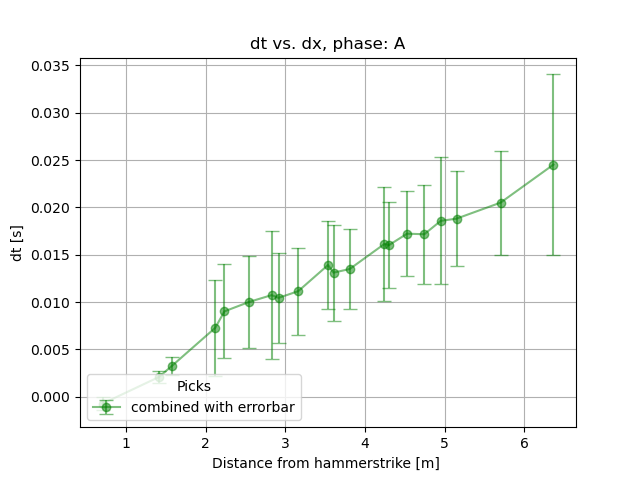

In [119]:
for p, phase in enumerate(df_picks['phase'].unique()):
    plt.figure()
    df_phase = df_picks[df_picks['phase'] == phase]

    for _, exp in enumerate(df_phase['experiment'].unique()):

        df_group = df_phase[df_phase['experiment'] == exp]
        grouped = df_group.groupby('distance_to_source')['dt'].agg(['mean', 'std']).reset_index()

        plt.errorbar(grouped['distance_to_source'], grouped['mean'], yerr=grouped['std'], color='g', fmt='o', linestyle='-', capsize=5, alpha=0.5, label='combined with errorbar')

    # Create a custom legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

    plt.xlabel('Distance from hammerstrike [m] ')
    plt.ylabel('dt [s]')
    plt.title('dt vs. dx, phase: %s' %phase)
    plt.grid(True)
    plt.show()


In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Make sure 'dt' is numeric
df_picks['dt'] = pd.to_numeric(df_picks['dt'], errors='coerce')

# Aggregate dt per station (you can add ['phase'] to groupby if desired)
df_station_mean = (
    df_picks.groupby(['experiment', 'sta', 'lon', 'lat'], as_index=False)['dt']
    .mean()
    .dropna(subset=['dt'])
)


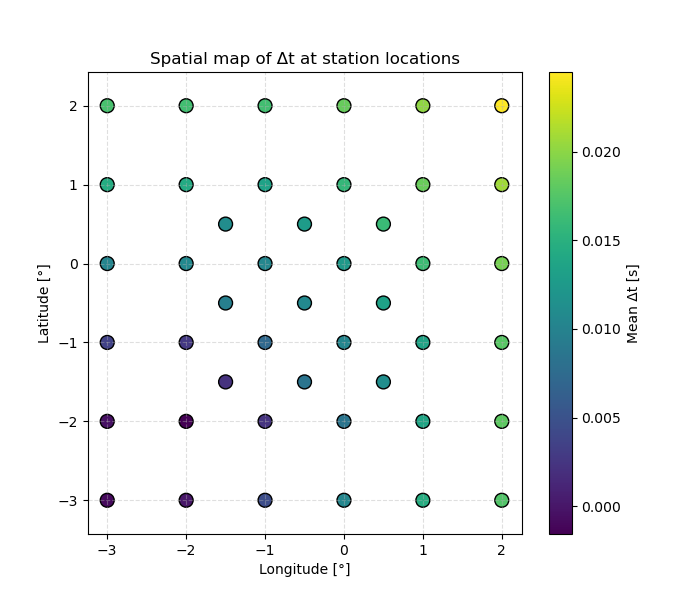

In [121]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    df_station_mean['lon'], df_station_mean['lat'],
    c=df_station_mean['dt'], cmap='viridis', s=100, edgecolors='k'
)
plt.colorbar(sc, label='Mean Δt [s]')
plt.xlabel('Longitude [°]')
plt.ylabel('Latitude [°]')
plt.title('Spatial map of Δt at station locations')
plt.grid(True, linestyle='--', alpha=0.4)
plt.axis('equal')
plt.show()

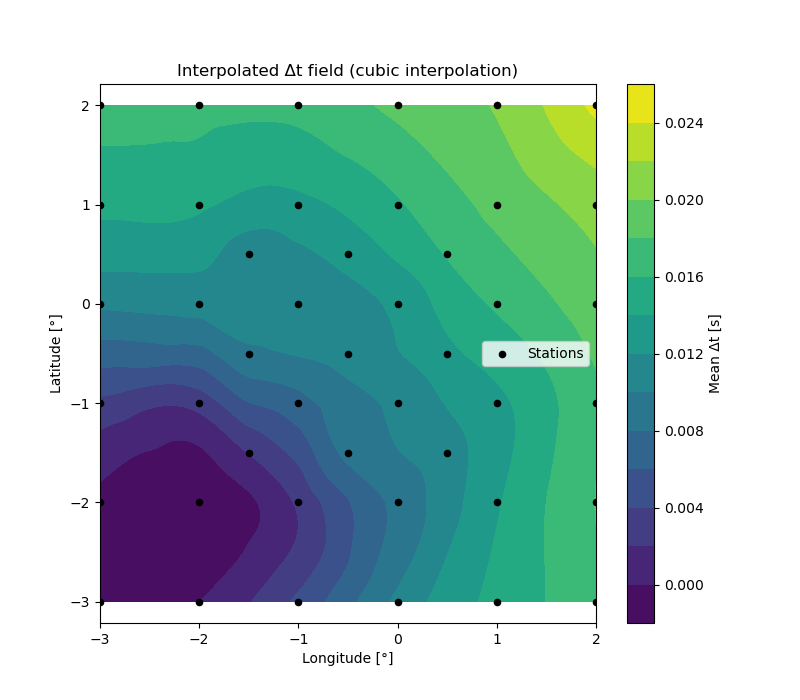

In [122]:
#### ONLY USE THIS IF YOU HAVE A 2D GRID OF STATION LOCATIONS ####

# Define interpolation grid
n_grid = 200
lon_grid = np.linspace(df_station_mean['lon'].min(), df_station_mean['lon'].max(), n_grid)
lat_grid = np.linspace(df_station_mean['lat'].min(), df_station_mean['lat'].max(), n_grid)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate using scipy.griddata
dt_grid = griddata(
    (df_station_mean['lon'], df_station_mean['lat']),
    df_station_mean['dt'],
    (lon_mesh, lat_mesh),
    method='cubic'  # can be 'linear', 'nearest', or 'cubic'
)

# Plot
plt.figure(figsize=(8, 7))
contour = plt.contourf(lon_mesh, lat_mesh, dt_grid, levels=15, cmap='viridis')
plt.scatter(df_station_mean['lon'], df_station_mean['lat'], c='k', s=20, label='Stations')
plt.colorbar(contour, label='Mean Δt [s]')
plt.xlabel('Longitude [°]')
plt.ylabel('Latitude [°]')
plt.title('Interpolated Δt field (cubic interpolation)')
plt.legend()
plt.axis('equal')
plt.show()

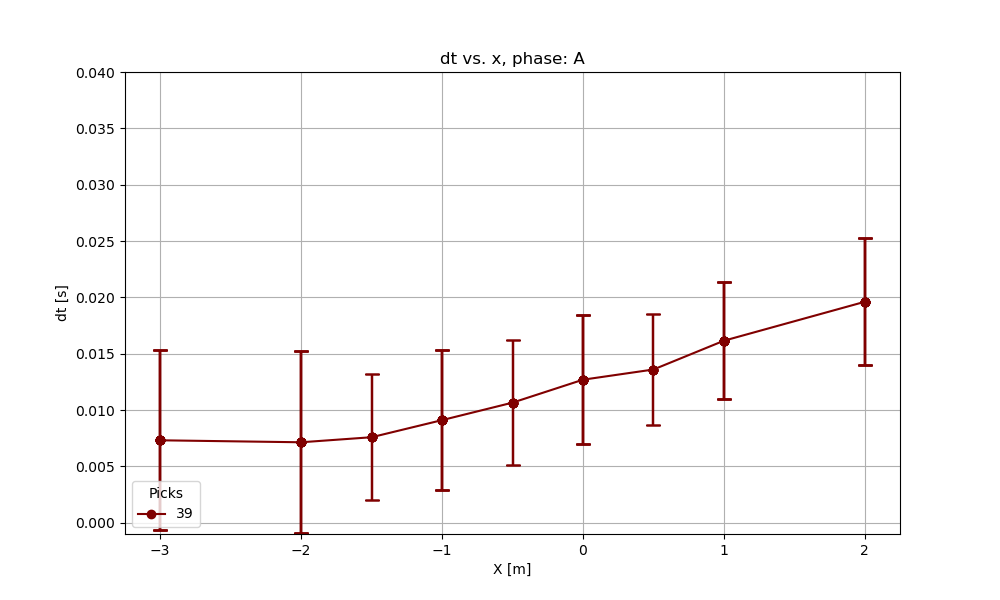

In [123]:
import matplotlib.colors as mcolors
collect_picks = []

for p, phase in enumerate(df_picks['phase'].unique()):
    df_phase = df_picks[df_picks['phase'] == phase]
    fig, ax = plt.subplots(figsize=(10, 6))

    # cmap = plt.get_cmap('jet_r')  # You can choose other colormaps like 'plasma', 'inferno', etc.
    # # cmap = plt.get_cmap('rainbow')  # You can choose other colormaps like 'plasma', 'inferno', etc.
    # norm = plt.Normalize(df_picks['experiment'].min(), df_picks['experiment'].max())

    # Create a colormap with distinct colors
    cmap = plt.get_cmap('jet_r')  # 'tab10' has 10 distinct colors
    norm = mcolors.Normalize(vmin=0, vmax=len(df_picks['experiment'].unique())-1)
    
    for j, exp in enumerate(df_phase['experiment'].unique()):
        if exp == 49: # leave out experiment 49
            continue
        
        df_group = df_phase[df_phase['experiment'] == exp]
        grouped = df_group.groupby('lon')['dt'].agg(['mean', 'std']).reset_index()
        grouped.rename(columns={'mean': 'mean_dt', 'std': 'std_dt'}, inplace=True)

        df_group = df_group.merge(grouped, on=['lon'], how='left')

        if j % 2 == 0:
            # ax.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(exp)))
            ax.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(j)))
        else:
            # ax.plot(grouped['lon'], grouped['mean_dt'], 'o--', label=exp,  color=cmap(norm(exp)))
            ax.plot(grouped['lon'], grouped['mean_dt'], 'o--', label=exp,  color=cmap(norm(j)))
        
        for i, row in df_group.iterrows():
            collect_picks.append([row['datetime'], row['session'],row['experiment'], row['net'], row['sta'], row['phase'], row['ev_lat'], row['ev_lon'], row['lat'], row['lon'], row['elev'], row['depth'], row['distance_to_source'], row['dt'], row['group'], row['mean_dt'], row['std_dt']])
            
            ax.errorbar(row['lon'], row['mean_dt'], yerr=row['std_dt'], fmt='o',  linestyle='-',capsize=5,  color=cmap(norm(j)))

    # print(grouped)

    # Create a custom legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

    ax.set_xlabel('X [m]')
    ax.set_ylabel('dt [s]')
    ax.set_title(f'dt vs. x, phase: {phase}')

    ax.set_ylim(-0.001, 0.04)
    ax.grid(True)
    plt.savefig(os.path.join(save_path, f"dt_vs_x_{phase}.png"))

    plt.show()

df_big = pd.DataFrame(collect_picks, columns = ['datetime', 'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat',
    'ev_lon', 'lat', 'lon', 'elev', 'depth', 'distance_to_source', 'dt',
    'group', 'mean', 'std']) 

df_big.to_csv(os.path.join(save_path, f"combined_strikes_with_mean_std.csv"))


## Picking the slopes

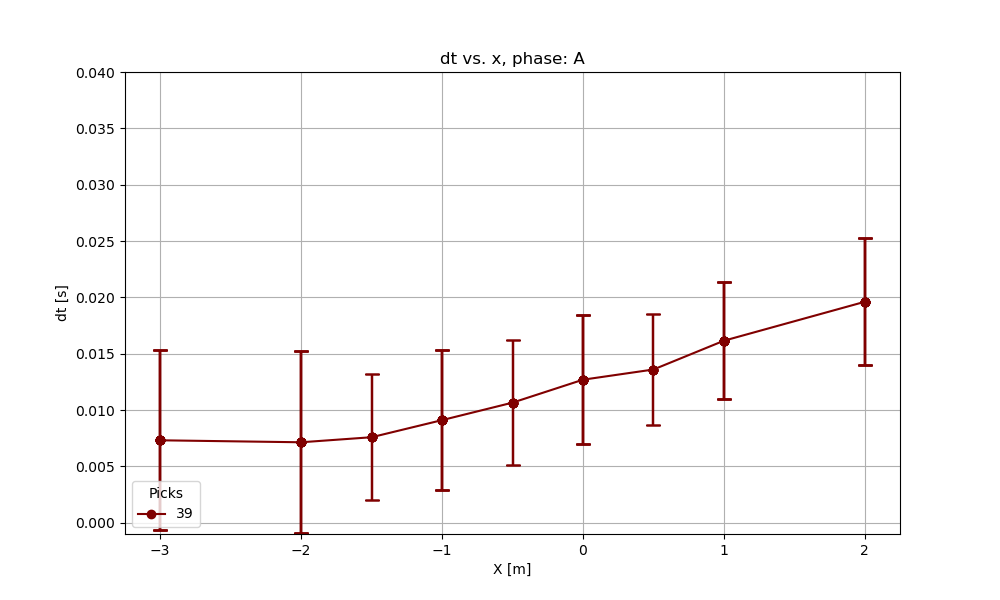

In [125]:
# ## Plotting the data and picking the points for slope calculation
# you have to click on two points to calculate the slope between them - it will be printed below the plot

phase = 'A'
df_phase = df_picks[df_picks['phase'] == phase]
fig, ax = plt.subplots(figsize=(10, 6))

cmap = plt.get_cmap('jet_r')  # 'tab10' has 10 distinct colors
norm = mcolors.Normalize(vmin=0, vmax=len(df_picks['experiment'].unique())-1)

for j, exp in enumerate(df_phase['experiment'].unique()):
    
    df_group = df_phase[df_phase['experiment'] == exp]
    grouped = df_group.groupby('lon')['dt'].agg(['mean', 'std']).reset_index()
    grouped.rename(columns={'mean': 'mean_dt', 'std': 'std_dt'}, inplace=True)

    df_group = df_group.merge(grouped, on=['lon'], how='left')

    if j % 2 == 0:
        ax.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(j)))
    else:
        ax.plot(grouped['lon'], grouped['mean_dt'], 'o--', label=exp,  color=cmap(norm(j)))
    
    for i, row in df_group.iterrows():
        ax.errorbar(row['lon'], row['mean_dt'], yerr=row['std_dt'], fmt='o',  linestyle='-',capsize=5,  color=cmap(norm(j)))

# Create a custom legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

ax.set_xlabel('X [m]')
ax.set_ylabel('dt [s]')
ax.set_title(f'dt vs. x, phase: {phase}')

ax.set_ylim(-0.001, 0.04)
ax.grid(True)
plt.savefig(os.path.join(save_path, f"dt_vs_x_{phase}.png"))
points = []

cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()